In [2]:
import sys
sys.path.append('../src/')
from xpcs import *
from sims import *
from autocorrelations import *
import cv2
from scipy.special import erfinv
import pyopencl as cl
from pathlib import Path
import json
from scipy.fft import fft, ifft, fftfreq

%matplotlib notebook


$$\bf{Notes}$$

$$
\begin{align}
&\text{-Plot all the rois on one plot. Try changing the center of the masks, binsize, numRings, numSlices and see if the results are consistent} \\
&\text{-Vegard's law} \\
&\text{|F(Q,t)| = aexp(-(t/$\tau_f$)^$\beta$) + (1-a)exp(-(t/$\tau_s$)^$\beta$)}\\
\end{align}
$$

# User Defined Variables 

$$
\begin{equation}
\text{|F($\bf{q}$,t)| = exp(-t/$\tau$($\bf{q}$))^$\beta$($\bf{q}$)}\\
\end{equation}
$$

In [44]:
### Beamline Parameters ###
Beamline = 'P10'
Geometry = 'Horizontal'
Compound = 'NPS'

### Analysis Parameters ###


### File Parameters ###
Particle = 2 #2,3,A7
Temperature = 298 #[298,305,315,325,345,365,385,405,350_cool] NBH = [320,329,339,360,380,399,420]
Scan = 219 #P2: [219,334,416,552,579,709,779,796,868], P3:[239,356 NBH = [343,344,349,353,358,362,363]
Attenuation = 20

#Crop Size
#number of standard deviations from peak
Xv = 5 
Xh = 5

#Binning Parameters
#Number of pixels in every direction to bin
#A bin size of 1 does not bin
binSize = 1

timeBatch = -1 #seconds
startTime = 0 #seconds

stability = False 

#Mask Parameters
New_Mask = True
Tilted_Mask = False
maskSize = 3 #standard deviations
numRings = 10  # Number of elliptical rings
numSlices = 1 # Number slices, should be even
tol = 0.02 # Percentage tolerance for converging to ring partition
res = 0.0001 # Resolution for ring size increments

#XPCS fitting parameters
a = 0.5
tt1 = 20
tt2 = 100
b1 = 2
b2 = 1
trunc = -18 # Cut last few points from fit
Double_Exp = True

#Constants 
notzero = 1.0**(-12)

# File Paths

In [45]:
# Define the path to the configuration file
config_path = Path("config.json")

# Open and load the JSON configuration file
with open(config_path, "r") as file:
    config = json.load(file)

#This is being written to handle multiple datasets of different formatting in different locations.
#Still working out the best way to handle, but base directories are now stored in a config.json file
#Subdirectories and file names still need to be defined here due to use of f-strings
if Compound == 'NBH':
    BASE_DIR       = Path(config.get("NBH_base"))
    #mask_path      = Path(config.get(f"NBH_Mask_Result_{Xv}x{Xh}"))
    dataset_name   = f'A{Scan}_NaBH_att0000{Attenuation}_{Temperature}K_001'
    subfolder      = f'A{Scan}_NaBH_att0000{Attenuation}_{Temperature}K_001'
    filename       = f'A{Scan}_NaBH_att0000{Attenuation}_{Temperature}K_001_001.hdf' 
    batchname      = f'A{Scan}_NaBH_att0000{Attenuation}_{Temperature}K_001_0001-3000.batchinfo' 
    #Set path to working directory
    work_path      = BASE_DIR / dataset_name 
    processed_path = work_path / 'processed' / f'particle{Particle}_temp{Temperature}K_scan{Scan}_crop{Xv}x{Xh}_NewMask{New_Mask}_stability{stability}.h5'
    results_path = work_path / 'results'
    results = results_path / f'particle{Particle}_temp{Temperature}K_scan{Scan}_crop{Xv}x{Xh}_ms{maskSize}_nr{numRings}ns{numSlices}_bin{binSize}_st{startTime}_tb{int(timeBatch)}_newmask{New_Mask}_tilt{Tilted_Mask}.h5'

if Compound == 'NPS':
    BASE_DIR       = Path(config.get("NPS_base"))
    mask_path      = Path(config.get(f"NPS_Mask_Result_{Xv}x{Xh}"))
    dataset_name   = f'Particle_{Particle}/{Temperature}K/NPS_01_00{Scan}'
    subfolder      = 'e4m'
    filename       = f'{Compound}_01_00{Scan}_master.h5'
    batchname      = f'{Compound}_01_00{Scan}.batchinfo'
    #Set path to working directory
    work_path      = BASE_DIR / dataset_name / subfolder
    #processed_path = work_path / 'processed' / f'particle{Particle}_temp{Temperature}K_scan{Scan}_crop{Xv}x{Xh}.h5'
    processed_path = work_path / 'processed' /f'particle{Particle}_temp{Temperature}K_scan{Scan}_crop{Xv}x{Xh}_NewMask{New_Mask}_stability{stability}.h5'
    
    results_path = work_path / 'results'
    results = results_path / f'particle{Particle}_temp{Temperature}K_scan{Scan}_crop{Xv}x{Xh}_ms{maskSize}_nr{numRings}ns{numSlices}_bin{binSize}_st{startTime}_tb{int(timeBatch)}_newmask{New_Mask}_tilt{Tilted_Mask}.h5'
    
    
#Check that path exists
if work_path.exists():
    print(f'Directory found: {work_path}')
else:
    print(f'Directory not found: {work_path}')

#Load File Names
file_list = np.sort(os.listdir(work_path)).tolist()

#Remove first element if it's DS_Store
if file_list[0] == '.DS_Store':
    file_list.remove(file_list[0])

#Removes strange file that occurs if you edit batchinfo
if file_list[0][0:2] == '._':
    file_list.remove(file_list[0])

print('Contains:') 
for f in file_list:
    print(f)

Directory found: /Users/eriklamb/Documents/Data/PETRA/PETRA_P10_November2023/Beamtime_11017686/XPCS_Scans/Particle_2/298K/NPS_01_00219/e4m
Contains:
NPS_01_00219.batchinfo
NPS_01_00219_data_000001.h5
NPS_01_00219_master.h5
NPS_01_10219.batchinfo
mask219.mat
mask219_2.mat
mask219_3.mat
mask219_cr.mat
processed
results


In [46]:
processed_path

PosixPath('/Users/eriklamb/Documents/Data/PETRA/PETRA_P10_November2023/Beamtime_11017686/XPCS_Scans/Particle_2/298K/NPS_01_00219/e4m/processed/particle2_temp298K_scan219_crop5x5_NewMaskTrue_stabilityFalse.h5')

# Load Data

In [4]:
#Set the path to the processed file 
#processed = processed_path+f'particle{Particle}_temp{Temperature}K_scan{Scan}_crop{Xv}x{Xh}.h5'

#Check that the processed file exists
if not os.path.exists(processed_path):
    print(f"File '{processed_path}' does not exist! Please create it in pre_processing.")

#Load file
with h5py.File(processed_path, 'r') as DATA:
    
    pixelSize    = DATA['experimental_parameters/pixel_size'][:][0]
    frameSpacing = DATA['experimental_parameters/frame_spacing'][:][0]
    nFrames      = DATA['experimental_parameters/nFrames'][:][0]
    tilt         = DATA['pre_processing/angular_tilt'][:][0]
    Qx           = DATA['pre_processing/Qx'][:]
    Qy           = DATA['pre_processing/Qy'][:]
    hSig         = DATA['pre_processing/hSig'][:][0]
    vSig         = DATA['pre_processing/vSig'][:][0]
    
    if timeBatch == -1:
        timeBatch = nFrames*frameSpacing
        
    POPT         = DATA['gaussian_fitting/POPT'][:][int(startTime//frameSpacing):int(startTime//frameSpacing)+int(timeBatch//frameSpacing),:]
    PCOV         = DATA['gaussian_fitting/PCOV'][:][int(startTime//frameSpacing):int(startTime//frameSpacing)+int(timeBatch//frameSpacing),:]
    
    
    #Take timeChunk of data. Not whole scan
    det          = DATA['data/det'][:][int(startTime//frameSpacing):int(startTime//frameSpacing)+int(timeBatch//frameSpacing),:,:]
    det_corr     = DATA['data/det_corr'][:][int(startTime//frameSpacing):int(startTime//frameSpacing)+int(timeBatch//frameSpacing),:,:]

    

# Check Peak Stability

In [5]:
nframes = det.shape[0]

#Store fit results
POPTX = np.zeros((nframes,4))
POPTY = np.zeros((nframes,4))

#Loop through each image
for t,im in enumerate(det):
    poptx,popty,_,_ = integrated_gaussian(im,stdy=50,stdx=10)
    POPTX[t,:] += poptx
    POPTY[t,:] += popty

<IPython.core.display.Javascript object>


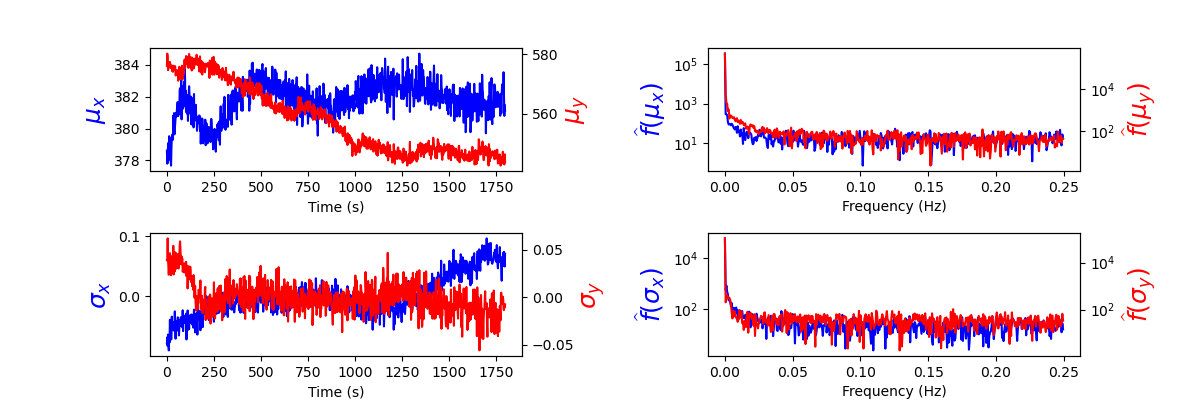

<function matplotlib.pyplot.show(*, block=None)>

In [6]:
fig,ax = plt.subplots(2,2)
fig.set_size_inches(12, 4)

ax2 = ax[0,0].twinx()
ax[0,0].plot(frameSpacing*np.arange(nframes),POPTX[:,1],'b')
ax2.plot(frameSpacing*np.arange(nframes),POPTY[:,1],'r')
ax[0,0].set_ylabel('$\\mu_{x}$',fontsize=18,color='blue')
ax2.set_ylabel('$\\mu_{y}$',fontsize=18,color='red')


ax4 = ax[0,1].twinx()
ax[0,1].semilogy(fftfreq(nframes,frameSpacing)[:nframes//2],np.abs(fft(POPTX[:,1])[:nframes//2]),'b')
ax4.semilogy(fftfreq(nframes,frameSpacing)[:nframes//2],np.abs(fft(POPTY[:,1])[:nframes//2]),'r')
ax[0,1].set_ylabel('$\\widehat{f}(\\mu_{x})$',fontsize=18,color='blue')
ax4.set_ylabel('$\\widehat{f}(\\mu_{y})$',fontsize=18,color='red')


ax[0,0].set_xlabel('Time (s)')
ax[0,1].set_xlabel('Frequency (Hz)')


ax6 = ax[1,0].twinx()
ax[1,0].plot(frameSpacing*np.arange(nframes),(POPTX[:,2]-np.mean(POPTX[:,2]))/np.mean(POPTX[:,2]),'b')
ax6.plot(frameSpacing*np.arange(nframes),(POPTY[:,2]-np.mean(POPTY[:,2]))/np.mean(POPTY[:,2]),'r')
ax[1,0].set_ylabel('$\\sigma_{x}$',fontsize=18,color='blue')
ax6.set_ylabel('$\\sigma_{y}$',fontsize=18,color='red')


ax8 = ax[1,1].twinx()
ax[1,1].semilogy(fftfreq(nframes,frameSpacing)[:nframes//2],np.abs(fft(POPTX[:,2])[:nframes//2]),'b')
ax8.semilogy(fftfreq(nframes,frameSpacing)[:nframes//2],np.abs(fft(POPTY[:,2])[:nframes//2]),'r')
ax[1,1].set_ylabel('$\\widehat{f}(\\sigma_{x})$',fontsize=18,color='blue')
ax8.set_ylabel('$\\widehat{f}(\\sigma_{y})$',fontsize=18,color='red')


ax[1,0].set_xlabel('Time (s)')
ax[1,1].set_xlabel('Frequency (Hz)')

plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show

#DO CENTER OF MASS, not Gaussian

# Mask Extraction

In [7]:
if not New_Mask:
    with h5py.File(mask_path, 'r') as DATA:
        masks = DATA['XPCS/Mask'][:]
        ringWidths = DATA['XPCS/ringWidths'][:]
        
    #For Plotting. Change -1s to 0s
    masks_plot = np.copy(masks)
    #masks_plot[masks_plot==-1] = 0

    for i in range(masks_plot.shape[0]):
        masks_plot[i,:,:] = (i+1)*masks_plot[i,:,:]
        
    #Sum of the masks for a single mask image
    mask_sum = np.sum(masks_plot,axis=0)
    
    
    fig, ax = plt.subplots()
    ax.imshow(mask_sum,'nipy_spectral',clim=(1,numRings*numSlices+3.5))

<IPython.core.display.Javascript object>


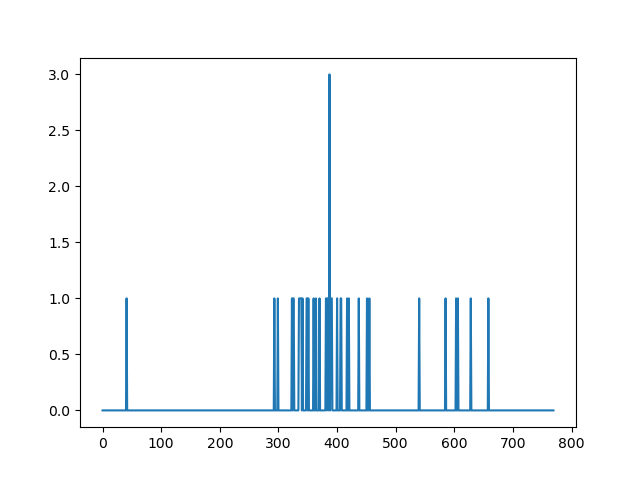

In [8]:
fig, ax = plt.subplots()

ax.plot(det[0,det.shape[1]//2,:])

# Bin Cropped Data and Q-Maps and Plot

<IPython.core.display.Javascript object>


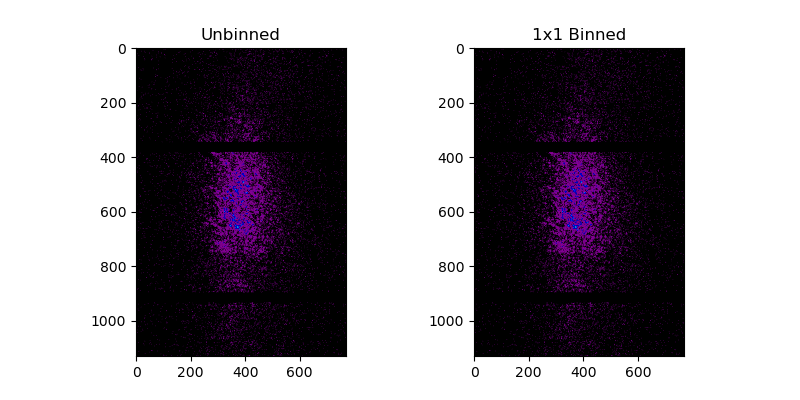

In [9]:
### Binning Section. Bin images as well as the Q maps ###
detBinned,_ = binning(det,binSize,pixelSize,'sum')
det_corr,_ = binning(det_corr,binSize,pixelSize,'sum')

### Bin the Q-Map according to the same binning as the detector ###
Qx,_ = binning(Qx,binSize,mode='mean')
Qy,_ = binning(Qy,binSize,mode='mean')

    
### Plotting ###
import matplotlib.pyplot as plt
%matplotlib notebook

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
#print(det.shape)

axs[0].imshow(np.sum(det[0:1,:,:],axis=0)+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=35))
axs[0].set_title('Unbinned')

axs[1].imshow(np.sum(detBinned[0:1,:,:],axis=0)+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=35*binSize))
axs[1].set_title('{}x{} Binned'.format(binSize,binSize))

#axs.axes.xaxis.set_visible(False)
#axs.axes.yaxis.set_visible(False)

#Det det to binned copy
det = np.copy(detBinned)

# Create Elliptical Mask

In [19]:
if New_Mask:
    
    if not Tilted_Mask:
        tilt = 0
        
    #hSig = np.mean(POPT[:,3])
    #VSig = np.mean(POPT[:,4])

    #Create Elliptical Masks. Non-masked regions are -1
    masks,ringWidths = const_int_mask(det,hSig/binSize,vSig/binSize,maskSize,numRings,numSlices,-tilt,tol,res) #Create the masks of equal intensity

    #For Plotting. Change -1s to 0s
    masks_plot = np.copy(masks)
    #masks_plot[masks_plot==-1] = 0

    for i in range(masks_plot.shape[0]):
        masks_plot[i,:,:] = (i+1)*masks_plot[i,:,:]

    #Sum of the masks for a single mask image
    mask_sum = np.sum(masks_plot,axis=0)
    
#if New_Mask == False:
#    masks,_ = binning(mask,binSize,'mean')


#Create the displacement in Q from Q0 for each mask
dQ = np.zeros(masks.shape[0])

#Find the center of the peak
Qx0 = Qx[Qx.shape[0]//2,Qx.shape[1]//2]
Qy0 = Qy[Qy.shape[0]//2,Qy.shape[1]//2]

#Calculate the mean displacement from the center for each ROI
for i in range(masks.shape[0]):
    dQ[i] = np.mean(np.sqrt((Qx-Qx0)**2+(Qy-Qy0)**2)[masks[i,:,:]==1])    

0.0981342155463742
0.0980277004421575
0.09803851790225106
0.09806722104920387
0.0980151620225036
0.0980175590733198
0.09804380370661497
0.09800901573835956
0.0980133181372604
0.09801313374873605
[0.4784 0.673  0.8471 1.0279 1.2243 1.4232 1.6549 2.0051 2.4156 2.8885]


<IPython.core.display.Javascript object>


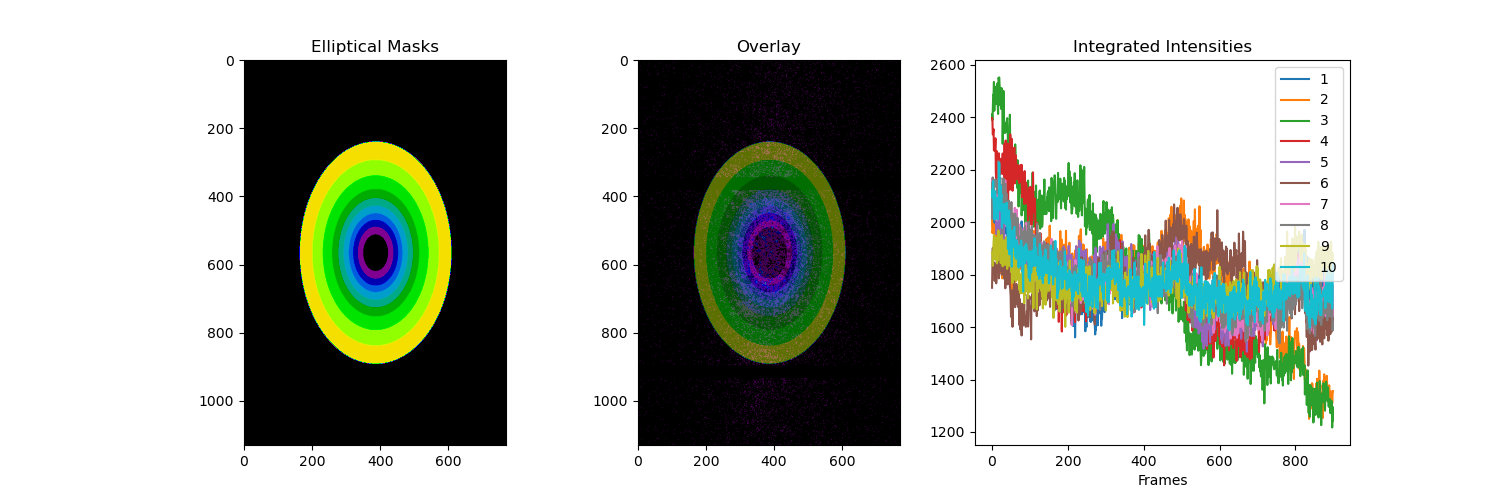

<function matplotlib.pyplot.show(*, block=None)>

In [20]:
### Plotting ###
import matplotlib.pyplot as plt
%matplotlib notebook

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
#print(det.shape)

#Plot the Masks alone, with labels
axs[0].imshow(mask_sum,'nipy_spectral',clim=(1,numRings*numSlices+3.5))
axs[0].set_title('Elliptical Masks')

#Plot the masks overlayed on the detector image
# Display the first image of mask sum
axs[1].imshow(mask_sum-1, cmap='nipy_spectral',clim =(1,numRings*numSlices+3), alpha=1)
# Overlay the second image with a 'plasma' color scale and some transparency
axs[1].imshow(np.sum(det[0:1,:,:],axis=0)+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=35*binSize),alpha=0.55)
axs[1].set_title('Overlay')


#Plot the integrated intensity of each mask region
#i=0
for i,m in enumerate(masks): 
    axs[2].plot(np.sum(det[:,m==1],axis=1),label='{}'.format(i+1))
    #i+=1
axs[2].set_title('Integrated Intensities')
axs[2].set_xlabel('Frames')
axs[2].legend()

plt.subplots_adjust(wspace=0.05, hspace=0.4)
plt.show

Save as a .npy array. 900 x Cropped peak. Send to Nelson for PCA ml.

# Per Pixel Intensity

900


<IPython.core.display.Javascript object>


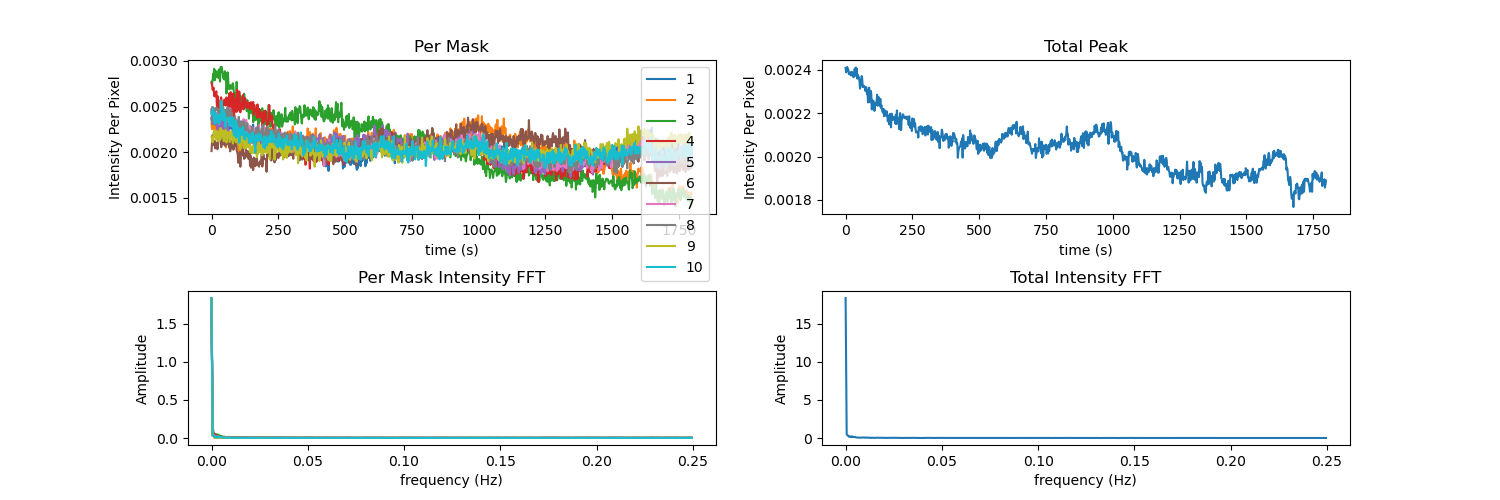

In [21]:
perPixelInt = np.zeros((masks.shape[0],det.shape[0]))
perMaskInt = np.zeros((masks.shape[0],det.shape[0]))

maskPix = 0

for i,m in enumerate(masks): 
    maskPix += np.size(m==1)
    perMaskInt[i,:] += np.sum(det[:,m==1],axis=1)
    perPixelInt[i,:] += np.sum(det[:,m==1],axis=1)/np.size(m==1)

print(perPixelInt.shape[1])
fig,ax = plt.subplots(2,2,figsize=(15,5))

time = frameSpacing*np.arange(0,perPixelInt.shape[1],1)
for i,ppi in enumerate(perPixelInt):
    ax[0,0].plot(time,ppi,label='{}'.format(i+1))
    ax[1,0].plot(fftfreq(nframes,frameSpacing)[:nframes//2],np.abs(fft(ppi)[:nframes//2]))

ax[0,1].plot(time,np.mean(perPixelInt,axis=0))
ax[1,1].plot(fftfreq(nframes,frameSpacing)[:nframes//2],np.abs(fft(np.sum(perPixelInt,axis=0))[:nframes//2]))


ax[0,1].set_xlabel('time (s)')
ax[0,1].set_ylabel('Intensity Per Pixel')  
ax[0,1].set_title('Total Peak')

ax[0,0].set_xlabel('time (s)')
ax[0,0].set_ylabel('Intensity Per Pixel')
ax[0,0].set_title('Per Mask')
ax[0,0].legend()


ax[1,0].set_xlabel('frequency (Hz)')
ax[1,0].set_ylabel('Amplitude')
ax[1,0].set_title('Per Mask Intensity FFT')

ax[1,1].set_xlabel('frequency (Hz)')
ax[1,1].set_ylabel('Amplitude')
ax[1,1].set_title('Total Intensity FFT')


plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

# Main Loop

In [22]:
#Calculate the G2 autocorrelations for the entire image
mask = np.ones(det.shape[1:])

#Delays per level. Increase for more sampling
dpl = 6

#IF are intensities future, intensities past. Used to normalize g2
sumI,G2,IF,IP,_ = g2calc(det[:,:,:],mask,dpl)

# Calculate Frame Spacing
nframes = det.shape[0]
delay = frameSpacing * finddelays(nframes,dpl,1)

<IPython.core.display.Javascript object>


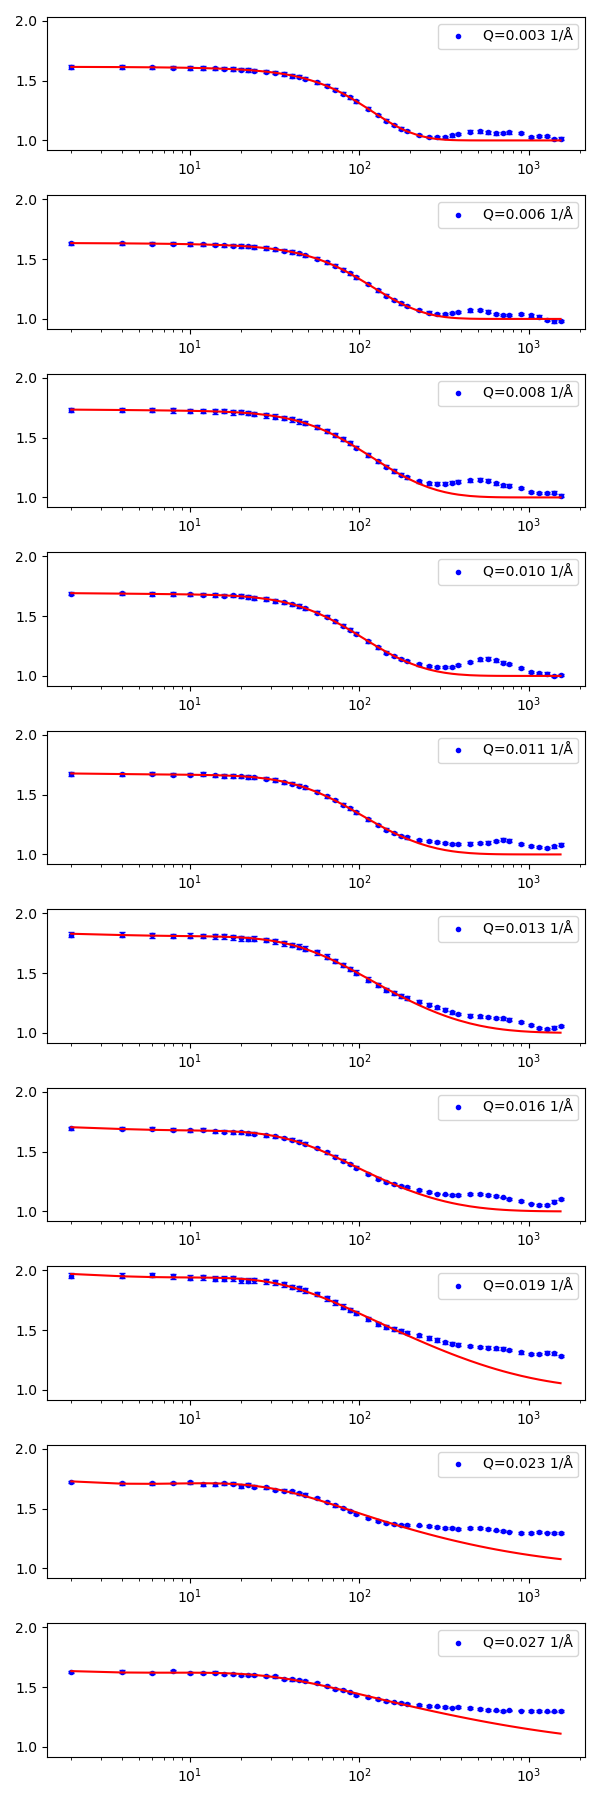

<function matplotlib.pyplot.show(*, block=None)>

In [29]:
#Used for stuff
if timeBatch == -1:
    timeBatch = nFrames*frameSpacing

#Results Arrays
G2_result = np.zeros((masks.shape[0],delay.shape[1]))
G2_error = np.zeros((masks.shape[0],delay.shape[1]))




if not Double_Exp:
    As = np.zeros(masks.shape[0])
    As_err = np.zeros(masks.shape[0])

    betas = np.zeros(masks.shape[0]) #Assumes one betas
    betas_err = np.zeros(masks.shape[0]) #Assumes one betas

    taus = np.zeros(masks.shape[0]) #Assumes one relaxation times
    taus_err = np.zeros(masks.shape[0]) #Assumes relaxation times
    
if Double_Exp:
    As = np.zeros(masks.shape[0])
    As_err = np.zeros(masks.shape[0])
    
    aas = np.zeros(masks.shape[0])
    aas_err = np.zeros(masks.shape[0])

    betas = np.zeros((masks.shape[0],2)) #Assumes two betas
    betas_err = np.zeros((masks.shape[0],2)) #Assumes two betas
    taus = np.zeros((masks.shape[0],2)) #Assumes two relaxation times
    taus_err = np.zeros((masks.shape[0],2)) #Assumes two relaxation times
    
    
    #aas = np.zeros(masks.shape[0])
    #aas_err = np.zeros(masks.shape[0])


if numSlices == 1 and numRings>1:
    fig,axs = plt.subplots(numRings,numSlices,figsize=(6,18), sharey=True) #FFT check
if numRings == 1 and numSlices>1:
    fig,axs = plt.subplots(numRings,numSlices,figsize=(24,6), sharey=True) #FFT check
#else:
#    fig,axs = plt.subplots(numRings,numSlices,figsize=(9.75,9), sharey=True)

# Indices for plotting
i=0
j=0

#Array for truncating fits
truncs = [trunc]*numRings*numSlices

for mm,m in enumerate(masks):
    
    #Used to single out specific scans for truncating the last few points
    if True:
        if mm==0:
            truncs[mm] = trunc
        if mm==1:
            truncs[mm] = trunc
    
    #Used to not truncate
    if truncs[mm] == 0:
        truncs[mm] = G2_result.shape[1]
        
    # Last bit of filtering 
    G2_masked = G2[:,m==1]

    # Removes the detector borders
    hot_pixel_mask = G2_masked[0,:] < 10**(10) 
    
    # Average and normalize g2s
    if np.abs(G2_masked.shape[0]-delay.shape[1])==0:
        last_index = G2_masked.shape[0]
    if np.abs(G2_masked.shape[0]-delay.shape[1])>0:
        last_index = -np.abs(G2_masked.shape[0]-delay.shape[1])

    # Initialize output arrays
    g2dummy = np.zeros_like(G2_masked)

    # Compute partition normalization factor (avoiding division by zero)
    part_norm = np.mean(IF[:, m == 1][:, hot_pixel_mask == 1],axis=1) * np.mean(IP[:, m == 1][:, hot_pixel_mask == 1], axis=1)

    # Normalize G2
    g2dummy = np.divide(G2_masked, part_norm[:, np.newaxis], out=np.full_like(G2_masked, np.nan), where=part_norm[:, np.newaxis] != 0)

    # Compute mean and standard error over the mask
    valid_pixels = hot_pixel_mask == 1

    G2_result[mm, :] += np.mean(g2dummy[:, valid_pixels][:last_index], axis=1)
    G2_error[mm, :] += np.std(g2dummy[:, valid_pixels][:last_index], axis=1) / np.sqrt(np.sum(valid_pixels))
    
    
    
    
    
    
    #G2_result[mm,:] += np.mean(G2_corr/np.mean(det_corr[:,m==1][:,hot_pixel_mask==1])**2,axis=1)[:last_index] 
    # G2_error[mm,:] += np.std(G2_corr/np.mean(det_corr[:,m==1][:,hot_pixel_mask==1])**2,axis=1)[:last_index]/np.float32(np.sqrt(G2_corr.shape[1]))
    #print(hot_mask)
    #G2_corr = G2_masked[:,hot_pixel_mask==1]
    
    #print(G2_corr.shape)
    #print((IF[:,m==1][:,hot_pixel_mask==1]*IP[:,m==1][:,hot_pixel_mask==1]).shape)
    

    """""""""
    g2dummy = np.zeros(G2_masked.shape)
    
    for td in range(G2_result.shape[1]):

        g2dummy[td,:] += G2_masked[td,:]/(np.mean(IF[td,m==1][hot_pixel_mask==1])*np.mean(IP[td,m==1][hot_pixel_mask==1])) #[:last_index] 
 
        G2_result[mm,td] += np.mean(g2dummy[td,:][hot_pixel_mask==1])
        G2_error[mm,td] += np.std(g2dummy[td,:][hot_pixel_mask==1])/np.float32(np.sqrt(np.size(g2dummy[td,:][hot_pixel_mask==1])))
    """""""""
    #G2_result[j,:] += np.mean(G2_corr,axis=1)[:last_index] /np.mean(IF[:,m==1][:,hot_pixel_mask==1]*IP[:,m==1][:,hot_pixel_mask==1],axis=1)[:last_index] 
    #G2_result[j,td] += np.mean(G2_corr,axis=1)/(np.mean(IF[td,m==1][td,hot_pixel_mask==1]*IP[:,m==1][:,hot_pixel_mask==1],axis=1)[:last_index] 
    
    #G2_error[j,td] += np.std(G2_corr[td,:]/(np.mean(IF[td,m==1][hot_pixel_mask==1])*np.mean(IP[td,m==1][hot_pixel_mask==1])))/np.float32(np.sqrt(G2_corr.shape[1])) #[:last_index]

    #G2_result[j,:] += np.mean(G2_corr/(IF[:,m==1][:,hot_pixel_mask==1]*IP[:,m==1][:,hot_pixel_mask==1]),axis=1)[:last_index] 
    #G2_error[j,td] += np.std(G2_corr)/np.mean(IF[:,m==1][:,hot_pixel_mask==1]*IP[:,m==1][:,hot_pixel_mask==1],axis=1)[:last_index]/np.float32(np.sqrt(G2_corr.shape[1]))

    #print(det_corr[:,m==1][:,hot_pixel_mask==1].shape)
    #print(G2_corr.shape)
               


    
    #Fit Each G2(Q)
    #Initial Guesses
    A = np.max(G2_result[mm,:truncs[mm]])-1

    if not Double_Exp:
        lower_bounds = [-np.inf,-np.inf,-np.inf]  # c >= 0
        upper_bounds = [np.inf,np.inf,np.inf]

        #Fit the g2s
        if mm == 0:
            popt, pcov = curve_fit(g2_exp, delay[0,:truncs[mm]], G2_result[mm,:truncs[mm]], p0=[A,tt1,b1],bounds=(lower_bounds, upper_bounds))
        else:
            popt, pcov = curve_fit(g2_exp, delay[0,:truncs[mm]], G2_result[mm,:truncs[mm]], p0=[As[mm-1],taus[mm-1],betas[mm-1]],bounds=(lower_bounds, upper_bounds))
        
        #Update fit results
        As[j] += popt[0]
        taus[j] += popt[1]
        betas[j] += popt[2]

        #Extract errors
        errors = np.sqrt(np.diag(pcov))

        As_err[j] += errors[0]
        taus_err[j] += errors[1]
        betas_err[j] += errors[2]
         
    if Double_Exp:
        lower_bounds = [-np.inf,-np.inf,-np.inf,-np.inf,-np.inf,-np.inf]  # c >= 0
        upper_bounds = [np.inf,np.inf,np.inf,np.inf,np.inf,np.inf]

        #Fit the g2s
        if mm == 0:
            popt, pcov = curve_fit(g2_two_tau, delay[0,:truncs[mm]], G2_result[mm,:truncs[mm]], p0=[A,a,tt1,tt2,b1,b2],bounds=(lower_bounds, upper_bounds))
        else:
            popt, pcov = curve_fit(g2_two_tau, delay[0,:truncs[mm]], G2_result[mm,:truncs[mm]], p0=[As[mm-1],aas[mm-1],taus[mm-1,0],taus[mm-1,1],betas[mm-1,0],betas[mm-1,1]],bounds=(lower_bounds, upper_bounds))

        #Update fit results
        As[j] += popt[0]
        aas[j] += popt[1]
        taus[j,:] += popt[2:4]
        betas[j,:] += popt[4:6]

        #Extract errors
        errors = np.sqrt(np.diag(pcov))

        As_err[j] += errors[0]
        aas_err[j] += popt[1]
        taus_err[j,:] += errors[2:4]
        betas_err[j,:] += errors[4:6]
    
    
    if numSlices == 1:
        #Add to the plots
        axs[j].errorbar(delay[0,:],G2_result[j,:], yerr=G2_error[j,:],fmt='none',ecolor='b',capsize=2)
        axs[j].semilogx(delay[0,:],G2_result[j,:],'b.',label='Q={:.3f} 1/Å'.format(dQ[j]))
        
        if not Double_Exp:
            axs[j].semilogx(delay[0,:],g2_exp(delay[0,:],*popt),'r-')
        if Double_Exp:
            axs[j].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
            
        axs[j].legend()
        
    if numSlices > 1 and numRings > 1:
        #Add to the plots
        axs[i%numRings,j%numSlices].errorbar(delay[0,:],G2_result[j,:], yerr=G2_error[j,:],fmt='none',ecolor='b',capsize=2)
        axs[i%numRings,j%numSlices].semilogx(delay[0,:],G2_result[j,:],'b.',label='Q={:.3f} 1/Å \n $\\phi$ ={:.0f} deg'.format(dQ[j],np.rad2deg(j%numSlices*(2*np.pi/numSlices))))
        if not Double_Exp:
            axs[i%numRings,j%numSlices].semilogx(delay[0,:],g2_exp(delay[0,:],*popt),'r-')
        if Double_Exp:
            axs[i%numRings,j%numSlices].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
        #axs[i%numRings,j%numSlices].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
        axs[i%numRings,j%numSlices].legend()
        
    if numSlices > 1 and numRings == 1:
        #Add to the plots
        axs[j%numSlices].errorbar(delay[0,:],G2_result[j,:], yerr=G2_error[j,:],fmt='none',ecolor='b',capsize=2)
        axs[j%numSlices].semilogx(delay[0,:],G2_result[j,:],'b.',label='Q={:.3f} 1/Å \n $\\phi$ ={:.0f} deg'.format(dQ[j],np.rad2deg(j%numSlices*(2*np.pi/numSlices))))
        if not Double_Exp:
            axs[j%numSlices].semilogx(delay[0,:],g2_exp(delay[0,:],*popt),'r-')
        if Double_Exp:
            axs[j%numSlices].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
        #axs[i%numRings,j%numSlices].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
        axs[j%numSlices].legend()
    
    """""""""
    #Update fit results
    Cs[j] += popt[0]
    As[j] += popt[1]
    aas[j] += popt[1]
    taus[j,:] += popt[3:5]
    betas[j] += popt[-1]
    
    #Extract errors
    errors = np.sqrt(np.diag(pcov))
    
    Cs_err[j] += errors[0]
    As_err[j] += errors[1]
    aas_err[j] += errors[1]
    taus_err[j,:] += errors[3:5]
    betas_err[j] += errors[-1]
    """""""""
    
    # Ensures each row is corresponds to a ring, each column to a slice. First row is inner most ring
    if j%numSlices == 3:
        i+=1
        
    j+=1
    
    

plt.tight_layout()       
plt.show

## Plot All g2s

<IPython.core.display.Javascript object>


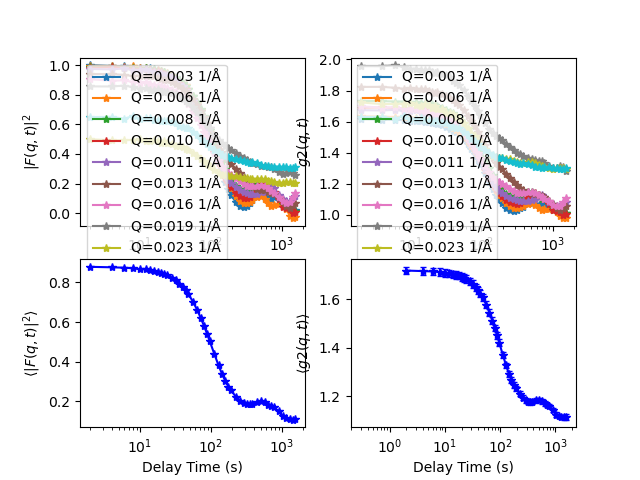

In [30]:
fig,ax = plt.subplots(2,2)

ISF = np.zeros(G2_result.shape)
ISFErr = np.zeros(G2_result.shape)

normG2 = np.zeros(G2_result.shape)
meanErr = np.zeros(G2_result.shape)

for i,g2,g2err,Q_label,AA in zip(range(G2_result.shape[0]),G2_result,G2_error,dQ,As):
    ax[0][0].semilogx(delay[0,:],(g2-1)/AA,'*-',label='Q={:.3f} 1/Å'.format(Q_label))
    ax[0][1].semilogx(delay[0,:],g2,'*-',label='Q={:.3f} 1/Å'.format(Q_label))
    
    normG2[i,:] += g2
    meanErr[i,:] += g2err**2
    
    ISF[i,:] += (g2-1)/AA
    ISFErr[i,:] += ((g2err-1)/AA)**2
    
    
ax[1][0].semilogx(delay[0,:],np.mean(ISF,axis=0),'b*-',label='Q={:.3f} 1/Å'.format(Q_label))
#ax[1][0].errorbar(delay[0,:],np.mean(ISF,axis=0), yerr=np.sqrt(np.mean(ISFErr,axis=0)),fmt='none',ecolor='b',capsize=2)

ax[1][1].semilogx(delay[0,:],np.mean(normG2,axis=0),'b*-',label='Q={:.3f} 1/Å'.format(Q_label))
ax[1][1].errorbar(delay[0,:],np.mean(normG2,axis=0), yerr=np.sqrt(np.mean(meanErr,axis=0)),fmt='none',ecolor='b',capsize=2)


#ax[1][0].set_xbound(lower=frameSpacing, upper=timeBatch)
#ax[1][1].set_xbound(lower=frameSpacing, upper=timeBatch)


    #ax.semilogx(delay[0,:],g2_exp(delay[0,:],*popt),'r-')
ax[0][0].set_ylabel('$|F(q,t)|^2$')
ax[0][0].set_xlabel('Delay Time (s)')

ax[0][1].set_ylabel('$g2(q,t)$')
ax[0][1].set_xlabel('Delay Time (s)')

ax[1][0].set_ylabel(r'$\langle|F(q,t)|^2\rangle$')
ax[1][0].set_xlabel('Delay Time (s)')

ax[1][1].set_ylabel(r'$\langle g2(q,t) \rangle$')
ax[1][1].set_xlabel('Delay Time (s)')



ax[0][0].legend()
ax[0][1].legend()

plt.show()

<IPython.core.display.Javascript object>


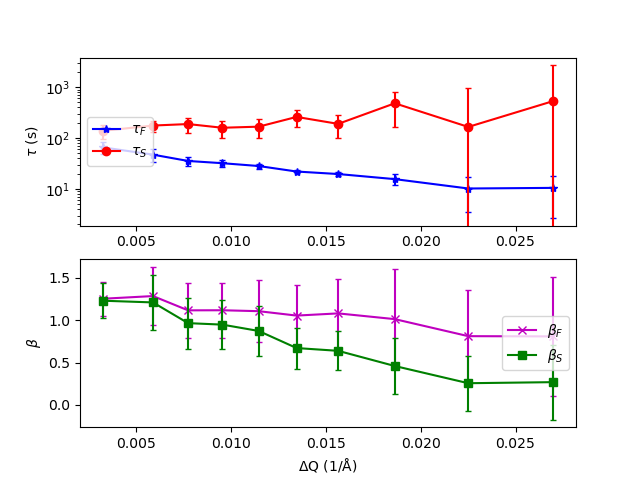

"\n### BINNED PLOTTING ### \n#Bin the arrays by ring\n#Bin the taus\nif not Double_Exp:\n    tau1_Qbin = np.mean(taus.reshape(numRings,taus.shape[0]//numRings),axis=1)\n    tau1err_Qbin = np.mean(taus_err.reshape(numRings,taus_err.shape[0]//numRings),axis=1)\nif Double_Exp:\n    tau1_Qbin = np.mean(taus[:,0].reshape(numRings,taus[:,0].shape[0]//numRings),axis=1)\n    tau1err_Qbin = np.mean(taus_err[:,0].reshape(numRings,taus_err[:,0].shape[0]//numRings),axis=1)\n\n    tau2_Qbin = np.mean(taus[:,1].reshape(numRings,taus[:,1].shape[0]//numRings),axis=1)\n    tau2err_Qbin = np.mean(taus_err[:,1].reshape(numRings,taus_err[:,1].shape[0]//numRings),axis=1)\n    \n    aas_Qbin = np.mean(aas.reshape(numRings,aas.shape[0]//numRings),axis=1)\n    aaserr_Qbin = np.mean(aas_err.reshape(numRings,aas_err.shape[0]//numRings),axis=1)\n    \n#Bin the rest\ndQ_QBin = np.mean(dQ.reshape(numRings,dQ.shape[0]//numRings),axis=1)\n\nbetas_Qbin = np.mean(betas.reshape(numRings,betas.shape[0]//numRings),axis=1

In [31]:
### UNBINNED PLOTTING ###
# Plotting 
fig, axs = plt.subplots(2,1)

# tau plot
if not Double_Exp:
    axs[0].errorbar(dQ,taus, yerr=taus_err,fmt='none',ecolor='b',capsize=2)
    axs[0].semilogy(dQ,taus,'b-*',label='$\\tau_F$')
    #axs[0].set_xlabel('$\\Delta$Q (1/Å)')
    axs[0].set_ylabel('$\\tau$ (s)')
    axs[0].legend(loc = 'center left')
    
    # beta plot
    axs[1].plot(dQ,betas,'m-x',label='$\\beta$')
    axs[1].errorbar(dQ,betas,yerr=betas_err,fmt='none',ecolor='m',capsize=2)
    axs[1].set_xlabel('$\\Delta$Q (1/Å)')
    axs[1].set_ylabel('$\\beta$')
    axs[1].legend(loc = 'center right')



if Double_Exp:
    axs[0].errorbar(dQ,taus[:,0], yerr=taus_err[:,0],fmt='none',ecolor='b',capsize=2)
    axs[0].semilogy(dQ,taus[:,0],'b-*',label='$\\tau_F$')
    axs[0].errorbar(dQ,taus[:,1], yerr=taus_err[:,1],fmt='none',ecolor='r',capsize=2)
    axs[0].semilogy(dQ,taus[:,1],'r-o',label='$\\tau_S$')
    #axs[0].set_xlabel('$\\Delta$Q (1/Å)')
    axs[0].set_ylabel('$\\tau$ (s)')
    axs[0].legend(loc = 'center left')
    #axs[0].xaxis.set_visible(False)
    
    # beta plot
    axs[1].plot(dQ,betas[:,0],'m-x',label='$\\beta_F$')
    axs[1].errorbar(dQ,betas[:,0],yerr=betas_err[:,0],fmt='none',ecolor='m',capsize=2)
    axs[1].plot(dQ,betas[:,1],'g-s',label='$\\beta_S$')
    axs[1].errorbar(dQ,betas[:,1],yerr=betas_err[:,1],fmt='none',ecolor='g',capsize=2)
    axs[1].set_xlabel('$\\Delta$Q (1/Å)')
    axs[1].set_ylabel('$\\beta$')
    axs[1].legend(loc = 'center right')



"""""""""
if Double_Exp:
    # a plot
    axs2 = axs[1].twinx()
    axs2.errorbar(dQ,aas,yerr=aas_err,fmt='none',ecolor='g',capsize=2)
    axs2.plot(dQ,aas,'g-s',label='a')
    #axs[1].semilogy(dQ_sorted,betas_sorted[:,1],'r-o',label='$\\beta_2$')
    axs2.set_xlabel('$\\Delta$Q (1/Å)')
    axs2.set_ylabel('a')
    axs2.legend(loc = 'center left')
"""""""""

plt.show()

"""""""""
### BINNED PLOTTING ### 
#Bin the arrays by ring
#Bin the taus
if not Double_Exp:
    tau1_Qbin = np.mean(taus.reshape(numRings,taus.shape[0]//numRings),axis=1)
    tau1err_Qbin = np.mean(taus_err.reshape(numRings,taus_err.shape[0]//numRings),axis=1)
if Double_Exp:
    tau1_Qbin = np.mean(taus[:,0].reshape(numRings,taus[:,0].shape[0]//numRings),axis=1)
    tau1err_Qbin = np.mean(taus_err[:,0].reshape(numRings,taus_err[:,0].shape[0]//numRings),axis=1)

    tau2_Qbin = np.mean(taus[:,1].reshape(numRings,taus[:,1].shape[0]//numRings),axis=1)
    tau2err_Qbin = np.mean(taus_err[:,1].reshape(numRings,taus_err[:,1].shape[0]//numRings),axis=1)
    
    aas_Qbin = np.mean(aas.reshape(numRings,aas.shape[0]//numRings),axis=1)
    aaserr_Qbin = np.mean(aas_err.reshape(numRings,aas_err.shape[0]//numRings),axis=1)
    
#Bin the rest
dQ_QBin = np.mean(dQ.reshape(numRings,dQ.shape[0]//numRings),axis=1)

betas_Qbin = np.mean(betas.reshape(numRings,betas.shape[0]//numRings),axis=1)
betaserr_Qbin = np.mean(betas_err.reshape(numRings,betas.shape[0]//numRings),axis=1)



fig, axs = plt.subplots(2,1)

# tau plot
if not Double_Exp:
    axs[0].errorbar(dQ_QBin,tau1_Qbin, yerr=tau1err_Qbin,fmt='none',ecolor='b',capsize=2)
    axs[0].semilogy(dQ_QBin,tau1_Qbin,'b-*',label='$\\tau_F$')
    #axs[0].set_xlabel('$\\Delta$Q (1/Å)')
    axs[0].set_ylabel('$\\tau$ (s)')
    axs[0].legend(loc = 'upper left')
    #axs[0].xaxis.set_visible(False)
if Double_Exp:
    axs[0].errorbar(dQ_QBin,tau1_Qbin, yerr=tau1err_Qbin,fmt='none',ecolor='b',capsize=2)
    axs[0].semilogy(dQ_QBin,tau1_Qbin,'b-*',label='$\\tau_F$')
    axs[0].errorbar(dQ_QBin,tau2_Qbin, yerr=tau2err_Qbin,fmt='none',ecolor='r',capsize=2)
    axs[0].semilogy(dQ_QBin,tau2_Qbin,'r-o',label='$\\tau_S$')
    #axs[0].set_xlabel('$\\Delta$Q (1/Å)')
    axs[0].set_ylabel('$\\tau$ (s)')
    axs[0].legend(loc = 'upper left')
    #axs[0].xaxis.set_visible(False)

# beta plot
axs[1].plot(dQ_QBin,betas_Qbin,'m-x',label='$\\beta$')
axs[1].errorbar(dQ_QBin,betas_Qbin,yerr=betaserr_Qbin,fmt='none',ecolor='m',capsize=2)
axs[1].set_xlabel('$\\Delta$Q (1/Å)')
axs[1].set_ylabel('$\\beta$')
axs[1].legend(loc = 'upper right')

if Double_Exp:
    # a plot
    axs2 = axs[1].twinx()
    axs2.errorbar(dQ_QBin,aas_Qbin,yerr=aaserr_Qbin,fmt='none',ecolor='g',capsize=2)
    axs2.plot(dQ_QBin,aas_Qbin,'g-s',label='a')
    #axs[1].semilogy(dQ_sorted,betas_sorted[:,1],'r-o',label='$\\beta_2$')
    axs2.set_xlabel('$\\Delta$Q (1/Å)')
    axs2.set_ylabel('a')
    axs2.legend(loc = 'upper left')

plt.show()
"""""""""

## Average G2s

<IPython.core.display.Javascript object>


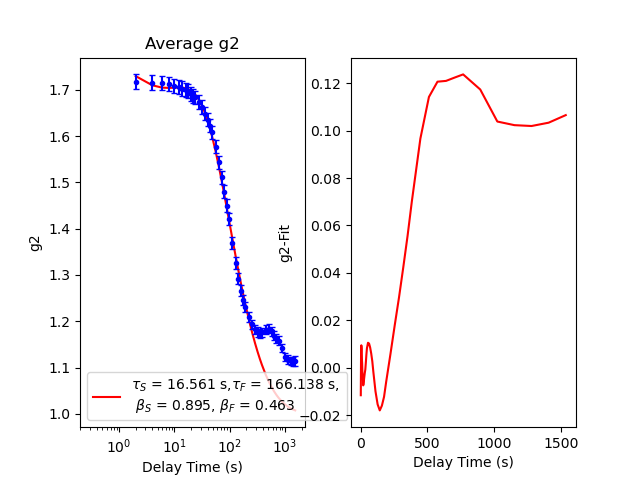

In [41]:
trunc = -15
 
#Used for stuff
if timeBatch == -1:
    timeBatch = nFrames*frameSpacing
    
#Used to not truncate
if trunc == 0:
    trunc = G2_result.shape[1]
        
#Average g2
#g = 
avgG2 = np.mean(G2_result[:,:],axis=0)
avgG2_err = np.sqrt(np.sum(G2_error[:,:]**2,axis=0)/(G2_error[:,:].shape[0]))

if not Double_Exp:
    #Average Fit results
    avgAs = np.mean(As)
    avgtaus = np.mean(taus,axis=0)
    avgbetas = np.mean(betas,axis=0)

    #Fit
    lower_bounds = [0,0,0]  # c >= 0
    upper_bounds = [np.inf,np.inf,np.inf]

    avgpopt, avgpcov = curve_fit(g2_exp, delay[0,:trunc], avgG2[:trunc], p0=[avgAs,avgtaus,avgbetas],bounds=(lower_bounds, upper_bounds))

    avg_fit_err = np.sqrt(np.diag(avgpcov))
    
if Double_Exp:
    #Average Fit results
    avgAs = np.mean(As,axis=0)
    avgaas = np.mean(aas,axis=0)
    avgtaus = np.mean(taus,axis=0)
    avgbetas = np.mean(betas,axis=0)

    #Fit
    lower_bounds = [-np.inf,-np.inf,-np.inf,-np.inf,-np.inf,-np.inf]  # c >= 0
    upper_bounds = [np.inf,np.inf,np.inf,np.inf,np.inf,np.inf]

    avgpopt, avgpcov = curve_fit(g2_two_tau, delay[0,:trunc], avgG2[:trunc], p0=[avgAs,avgaas,avgtaus[0],avgtaus[1],avgbetas[0],avgbetas[1]],bounds=(lower_bounds, upper_bounds))

    avg_fit_err = np.sqrt(np.diag(avgpcov))

#Plot
fig,axs = plt.subplots(1,2)

if not Double_Exp:
    axs[0].semilogx(delay[0,:],g2_exp(delay[0,:],*avgpopt),'r-',label='$\\tau$ = {:.3f} s, $\\beta$ = {:.3f}'.format(avgpopt[1],avgpopt[2]))
    axs[0].errorbar(delay[0,:],avgG2, yerr=avgG2_err,fmt='none',ecolor='b',capsize=2)
    axs[0].semilogx(delay[0,:],avgG2,'b.')
    
    axs[1].semilogx(delay[0,:],avgG2-g2_exp(delay[0,:],*avgpopt),'r-',)
if Double_Exp:
    axs[0].semilogx(delay[0,:],g2_two_tau(delay[0,:],*avgpopt),'r-',label='$\\tau_S$ = {:.3f} s,$\\tau_F$ = {:.3f} s, \n $\\beta_S$ = {:.3f}, $\\beta_F$ = {:.3f}'.format(avgpopt[2],avgpopt[3],avgpopt[4],avgpopt[5]))
    axs[0].errorbar(delay[0,:],avgG2, yerr=avgG2_err,fmt='none',ecolor='b',capsize=2)
    axs[0].semilogx(delay[0,:],avgG2,'b.')
    
    axs[1].plot(delay[0,:],avgG2-g2_two_tau(delay[0,:],*avgpopt),'r-',label='$\\tau_S$ = {:.3f} s,$\\tau_F$ = {:.3f} s, \n $\\beta_S$ = {:.3f}, $\\beta_F$ = {:.3f}'.format(avgpopt[2],avgpopt[3],avgpopt[4],avgpopt[5]))
    
    
#axs[0].set_xbound(lower=0.25, upper=timeBatch)
axs[0].set_ylabel('g2')
axs[1].set_ylabel('g2-Fit')

axs[0].set_xlabel('Delay Time (s)')
axs[1].set_xlabel('Delay Time (s)')

axs[0].set_title('Average g2')
axs[0].legend()

# Two-Time Correlation

<IPython.core.display.Javascript object>


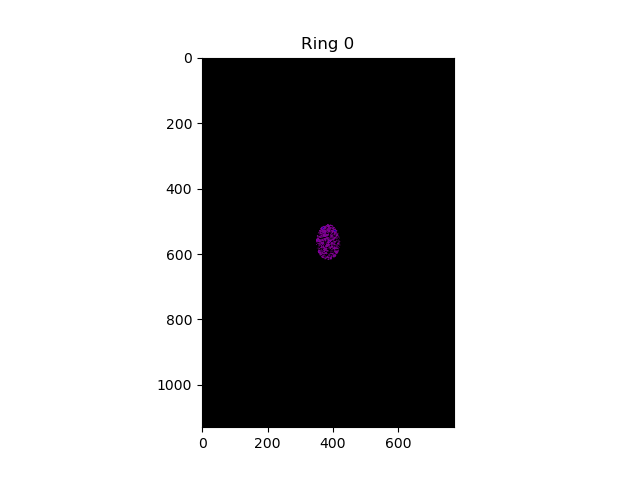

In [33]:
M = 0

# Plot ROI
fig, ax = plt.subplots()

#fig, ax = plt.subplots()
#make_detector_movie('mask0.gif', det*masks[M,:,:]+1, np.arange(1,det.shape[0]),frameSpacing, fig, ax, frameSpacing*2,scale='log',clims = [1,10])


# Overlay the second image with a 'plasma' color scale and some transparency
ax.imshow(np.sum(det[0:1,:,:],axis=0)*masks[M,:,:]+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=500))
#ax.imshow((det[:,:,:]*masks[M,:,:])[:,:,det.shape[2]//2].T+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=500))
ax.set_title(f'Ring {M}')
# Display the plot
plt.show()

In [34]:
IMG_temp = det[:,masks[M,:,:]==1]
#IMG_temp = det[:,mask_sum>0]
IMGS_NORM = IMG_temp.reshape((IMG_temp.shape[0],IMG_temp.shape[1],1))
#IMGS_NORM = IMG_temp.reshape((650,IMG_temp.shape[1],1))


C = twotime(IMGS_NORM)#/np.size(det[:,masks[M,:,:]==1])
C_extent = [0,frameSpacing*det.shape[0],0,frameSpacing*det.shape[0]]



<IPython.core.display.Javascript object>


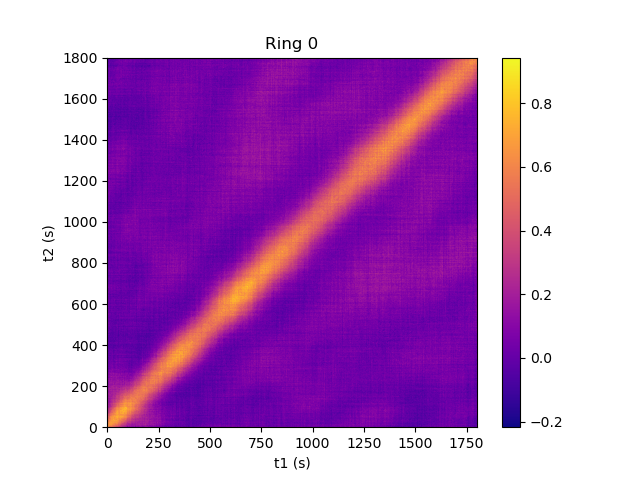

<function matplotlib.pyplot.show(*, block=None)>

In [35]:
import matplotlib.pyplot as plt
%matplotlib notebook

#C/np.size(det[:,masks[M,:,:]==1])
fig,ax = plt.subplots()
ax.set_ylabel('t2 (s)')
ax.set_xlabel('t1 (s)')
ax.set_title(f'Ring {M}')
#ax.set_title('Whole Mask')
im=ax.imshow(C,origin="lower",extent=C_extent,cmap='plasma')
fig.colorbar(im, ax=ax)

plt.show

# Waterfall

Try taking a series of line cuts: Central row/column, +2, +4, +8..

<IPython.core.display.Javascript object>


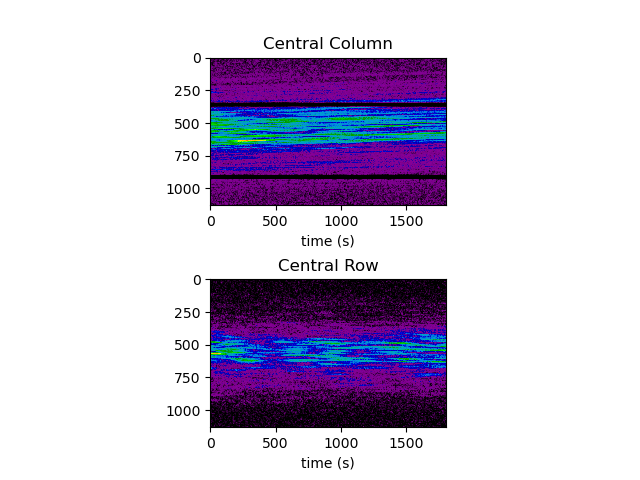

In [36]:
wfs = 1

if Geometry == "Horizontal":
    waterfall_col = np.sum(det[:,:,det.shape[2]//2-3:det.shape[2]//2+2],axis=2).T+1
    waterfall_row = np.sum(det[:,det.shape[1]//2-3:det.shape[1]//2+2,:],axis=1).T+1
if Geometry == "Vertical":
    waterfall_col = np.sum(det[:,:,det.shape[2]//2-3:det.shape[2]//2+2],axis=2).T+1
    waterfall_row = np.sum(det[:,det.shape[1]//2-3:det.shape[1]//2+2,:],axis=1).T+1


waterfall_extent = extent=[0,det.shape[0]*frameSpacing,det.shape[1],0]

fig, ax = plt.subplots(2,1)

ax[0].imshow(waterfall_col,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=waterfall_col.max()),extent=waterfall_extent)
ax[0].set_xlabel('time (s)')
ax[0].set_title('Central Column')

ax[1].imshow(waterfall_row,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=waterfall_row.max()),extent=waterfall_extent)
ax[1].set_xlabel('time (s)')
ax[1].set_title('Central Row')

plt.subplots_adjust(wspace=0.05, hspace=0.5)


# SAVE DATA

In [43]:
#Check that path exists. Make a new one if it does not 
#Save as a compressed hdf5
if not os.path.exists(results_path):
    os.mkdir(results_path)
    if os.path.exists(results_path):
        print(f"Directory '{results_path}' created!")

if not os.path.exists(results):
    # Save variables to the same HDF5 file
    with h5py.File(results, 'w') as h5file:
        # Create groups
        group1 = h5file.create_group('XPCS') #Analysis results
        #group2 = h5file.create_group('Intensity') #Analysis results

        
        # Create datasets for each variable
        group1.create_dataset('G2_Results', data=G2_result, compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('G2_error', data=G2_error, compression='gzip', compression_opts=9) #G2 error
        group1.create_dataset('delays', data=delay, compression='gzip', compression_opts=9) #delay times, x-axis for g2
        group1.create_dataset('dQ', data=dQ, compression='gzip', compression_opts=9) #dQ
        group1.create_dataset('taus', data=taus, compression='gzip', compression_opts=9) #relaxation times
        group1.create_dataset('taus_err', data=taus_err, compression='gzip', compression_opts=9) #relaxation times errors
        group1.create_dataset('betas', data=betas, compression='gzip', compression_opts=9) #betas
        group1.create_dataset('betas_err', data=betas_err, compression='gzip', compression_opts=9) #betas error
        group1.create_dataset('As', data=As, compression='gzip', compression_opts=9) #Amplitude
        group1.create_dataset('As_err', data=As_err, compression='gzip', compression_opts=9) #Amplitude error
        group1.create_dataset('aas', data=aas, compression='gzip', compression_opts=9) #Mixture (double exp only, zeros otherwise)
        group1.create_dataset('aas_err', data=aas_err, compression='gzip', compression_opts=9) #Mixture term error
        group1.create_dataset('AvgG2', data=avgG2, compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('AvgG2_error', data=avgG2_err, compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('AvgG2_fit', data=avgpopt, compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('AvgG2_fit_error', data=avg_fit_err, compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('TwoTime', data=C, compression='gzip', compression_opts=9) #TwoTime correlation matrix
        group1.create_dataset('TwoTime_extent', data=C_extent, compression='gzip', compression_opts=9) #TwoTime correlation matrix

        
        group1.create_dataset('Waterfall_Col', data=waterfall_col, compression='gzip', compression_opts=9) #TwoTime correlation matrix
        group1.create_dataset('Waterfall_Row', data=waterfall_row, compression='gzip', compression_opts=9) #TwoTime correlation matrix
        group1.create_dataset('Waterfall_extent', data=waterfall_extent, compression='gzip', compression_opts=9) #TwoTime correlation matrix
        group1.create_dataset('Mask', data=masks, compression='gzip', compression_opts=9) #Mask used
        group1.create_dataset('ringWidths', data=ringWidths, compression='gzip', compression_opts=9) #Mask used

        group1.create_dataset('frameSpacing', data=np.array([frameSpacing]), compression='gzip', compression_opts=9) #Mask used
        group1.create_dataset('Time', data=time, compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('perMaskInt', data=perMaskInt, compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('perPixelInt', data=perPixelInt, compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('TotalMaskInt', data=np.sum(perMaskInt,axis=0), compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('TotalPixelInt', data=np.mean(perPixelInt,axis=0), compression='gzip', compression_opts=9) #G2 results
               
    print(f"File '{f'particle{Particle}_temp{Temperature}K_scan{Scan}_crop{Xv}x{Xh}_ms{maskSize}_nr{numRings}ns{numSlices}_bin{binSize}_st{startTime}_tb{int(timeBatch)}_newmask{New_Mask}_tilt{Tilted_Mask}.h5'
}' saved!")

File 'particle2_temp345K_scan579_crop5x5_ms3_nr10ns1_bin1_st0_tb1800_newmaskTrue_tiltFalse.h5' saved!
